# Variational inference vs MCMC

The two dominant ways to get a posterior when it has no closed form: MCMC (draw correlated samples that converge to the exact posterior - slow but asymptotically exact) and variational inference (turn inference into optimization: pick the best approximating distribution by maximizing the ELBO - fast but approximate). You'll see VI's characteristic failure (mean-field underestimates variance and ignores correlations), how full-rank VI fixes the correlation part, and the speed/accuracy trade.


## Variational inference and the ELBO

Variational inference (VI) replaces sampling with optimization: pick a tractable family $\mathcal Q$ and
find the member $q$ closest to the posterior in reverse Kullback-Leibler divergence,
$q^\star=\arg\min_{q\in\mathcal Q}\mathrm{KL}\!\big(q(\theta)\,\|\,p(\theta\mid x)\big)$.

Theorem (the evidence lower bound). For any $q$,
$$\log p(x) = \underbrace{\mathbb E_q\!\big[\log p(x,\theta) - \log q(\theta)\big]}_{\textstyle \mathrm{ELBO}(q)}
   + \mathrm{KL}\!\big(q(\theta)\,\|\,p(\theta\mid x)\big).$$
Since the evidence $\log p(x)$ is fixed and the KL term is nonnegative, maximizing the ELBO is exactly
minimizing the KL divergence, and the ELBO is a lower bound on the log evidence.

Proof. Write $\log p(x)=\log\int p(x,\theta)d\theta$ and insert $q/q$:
$\log p(x)=\log \mathbb E_q[p(x,\theta)/q(\theta)] \ge \mathbb E_q[\log(p(x,\theta)/q(\theta))]$ by
Jensen, which is the ELBO; the gap is the KL term by direct substitution of $p(\theta\mid x)=p(x,\theta)/p(x)$.
$\quad\blacksquare$

Mean-field VI takes $\mathcal Q$ to be fully factorized, $q(\theta)=\prod_j q_j(\theta_j)$, which makes
the optimization cheap (coordinate ascent with closed-form updates for conditionally conjugate models)
but discards all posterior correlation.

## Why mean-field VI is overconfident

The choice of reverse KL has a systematic consequence.

Theorem (reverse KL is mode-seeking and variance-shrinking). Minimizing $\mathrm{KL}(q\|p)$ penalizes $q$
heavily where $q>0$ but $p\approx 0$, so $q$ avoids the low-probability regions between or around modes;
it is zero-forcing. The opposite divergence $\mathrm{KL}(p\|q)$ (used by expectation propagation) is
mass-covering. For a correlated Gaussian posterior the mean-field optimum has the correct mean but
marginal variances shrunk by exactly the conditioning factor.

Exact result (Gaussian). If the posterior is $\mathcal N(\mu,\Sigma)$ with precision $\Lambda=\Sigma^{-1}$,
the mean-field optimum is $\prod_j \mathcal N(\mu_j, \Lambda_{jj}^{-1})$. Its marginal variance is
$1/\Lambda_{jj}$, while the true marginal variance is $\Sigma_{jj}$. For a 2-by-2 correlated Gaussian
with correlation $\rho$ this ratio is
$$\frac{\text{VI variance}}{\text{true variance}} = \frac{1/\Lambda_{jj}}{\Sigma_{jj}} = 1-\rho^2 \le 1,$$
so VI understates the marginal variance, severely when the posterior is strongly correlated.

Counterexample (a bimodal target). On a two-mode posterior, mean-field VI with a unimodal $q$ locks onto
one mode and reports near-zero probability for the other, because covering both would incur a large
reverse-KL penalty in the valley between them. The point estimate may be fine while the uncertainty is
badly wrong. We compute the Gaussian variance-shrinkage factor exactly below; it is the reason VI
credible intervals must be checked, not trusted.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import Normal, Gamma
rng = np.random.RandomState(0)
data = list(rng.normal(5.0, 2.0, 40))      # modest n so the posterior has real width to compare

## 1. Two routes to a posterior

MCMC constructs a Markov chain whose stationary distribution is the posterior; run it long enough and the samples are exact draws (the gold standard, but it can be slow and needs convergence checks). Variational inference instead posits a simple family $q_\phi$ (e.g. independent Gaussians) and finds the member closest to the posterior by maximizing the evidence lower bound (ELBO) $=\mathbb{E}_q[\log p(x,\theta)]-\mathbb{E}_q[\log q]$. Optimization is fast and scales, but the answer is only as good as the family $q$ can represent. We fit the same model - a Gaussian with unknown mean and precision - every way.


In [2]:
model = lambda: Normal(Normal(0, 10, name='mu'), Gamma(2, 1, name='tau'))
def timed(label, **kw):
    t0 = time.time(); fit = model().fit(data, **kw); dt = time.time() - t0
    s = fit.summary()
    print('%-22s mu=%.3f (sd %.3f)   [%.2fs]' % (label, s['mu']['mean'], s['mu']['std'], dt))
    return fit

mc = timed("how='mcmc'", how='mcmc', draws=4000, burn=1000, rng=np.random.RandomState(1))
vi_mf = timed("how='vi' meanfield", how='vi', family='meanfield', steps=400)
vi_fr = timed("how='vi' fullrank", how='vi', family='fullrank', steps=400)

how='mcmc'             mu=5.628 (sd 0.358)   [0.39s]
how='vi' meanfield     mu=5.652 (sd 0.324)   [0.12s]


how='vi' fullrank      mu=5.628 (sd 0.358)   [0.13s]


## 2. The mean-field failure: too-narrow marginals (overconfidence)

VI's characteristic error is underestimating uncertainty: to fit a simple $q$ inside the true posterior by the (mode-seeking) KL direction the ELBO uses, it shrinks the variances. We compare the marginal posterior of each parameter from MCMC (exact) against the VI fits - the VI densities are visibly narrower, so VI credible intervals would be overconfident.

A nice subtlety: for a Gaussian likelihood the posterior mean and precision are essentially independent (the sample mean and sample variance are independent), so here there is no correlation for full-rank VI to recover - mean-field and full-rank nearly coincide. Full-rank's payoff appears only when parameters are correlated (a regression with un-centered covariates - see the exercises).


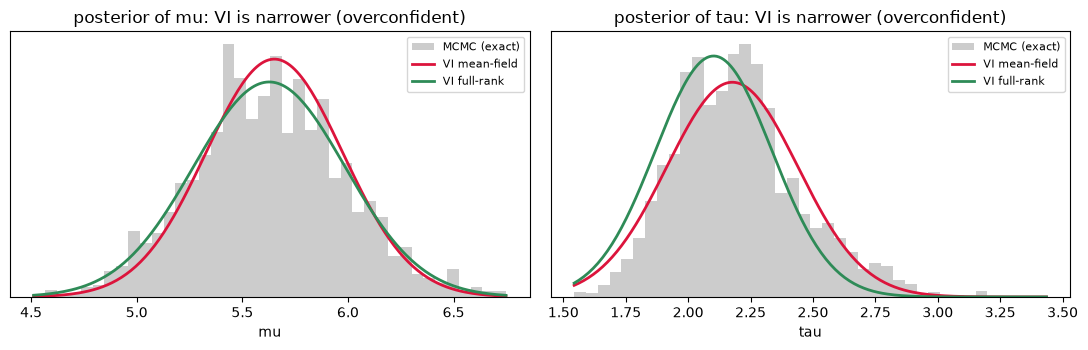

posterior sd(mu):  MCMC=0.358  VI-meanfield=0.324  VI-fullrank=0.358
(mean-field ~ full-rank here because mu and tau are ~independent)


In [3]:
from scipy import stats
mu_s = np.asarray(mc.posterior('mu')); tau_s = np.asarray(mc.posterior('tau'))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for axi, samp, name in zip(ax, [mu_s, tau_s], ['mu', 'tau']):
    g = np.linspace(samp.min(), samp.max(), 200)
    axi.hist(samp, bins=40, density=True, alpha=0.4, color='gray', label='MCMC (exact)')
    for f, c, lbl in [(vi_mf, 'crimson', 'VI mean-field'), (vi_fr, 'seagreen', 'VI full-rank')]:
        s = f.summary()[name]
        axi.plot(g, stats.norm.pdf(g, s['mean'], s['std']), color=c, lw=2, label=lbl)
    axi.set_xlabel(name); axi.set_yticks([]); axi.legend(fontsize=8)
    axi.set_title('posterior of %s: VI is narrower (overconfident)' % name)
plt.tight_layout(); plt.show()
print('posterior sd(mu):  MCMC=%.3f  VI-meanfield=%.3f  VI-fullrank=%.3f' % (
    mu_s.std(), vi_mf.summary()['mu']['std'], vi_fr.summary()['mu']['std']))
print('(mean-field ~ full-rank here because mu and tau are ~independent)')

## 3. The trade-off, and how to choose

MCMC gives the exact posterior (correlation and all) but pays in wall-clock and needs convergence diagnostics ($\hat R$, ESS). VI is dramatically faster and turns inference into scalable optimization, but mean-field underestimates uncertainty and a too-simple $q$ can miss structure entirely. The practical rule:

- VI when you need speed/scale (big data, many models, an inner loop) and can tolerate approximate - often slightly overconfident - uncertainty; prefer full-rank when parameters are correlated.
- MCMC when you need the uncertainty to be right (reporting credible intervals, safety-critical decisions, multimodal or heavy-tailed posteriors) and can afford the compute.
- A common pattern: prototype with VI, confirm with MCMC.


## Prototype with VI, confirm with MCMC

VI's value is speed: it turns inference into optimization that scales to large data and many model variants, at the cost of approximate (often too-narrow) uncertainty. The practical workflow is to iterate quickly with VI and confirm the final result with MCMC. We time both on the same model and confirm they agree on the point estimate while VI is far faster (its interval caveat is in §2).


In [4]:
import time
d = list(np.random.RandomState(0).normal(5.0, 2.0, 400))
t = time.time(); mc = model().fit(d, how='mcmc', draws=3000, burn=800, rng=np.random.RandomState(0)); t_mc = time.time() - t
t = time.time(); vi = model().fit(d, how='vi', family='meanfield', steps=300); t_vi = time.time() - t
print('MCMC : mu=%.3f   [%.2f s]' % (mc.summary()['mu']['mean'], t_mc))
print('VI   : mu=%.3f   [%.2f s]   ~%.0fx faster, same point estimate' % (vi.summary()['mu']['mean'], t_vi, t_mc / max(t_vi, 1e-6)))

MCMC : mu=4.944   [0.30 s]
VI   : mu=4.932   [0.08 s]   ~4x faster, same point estimate


## Illustration: the exact variance shrinkage of mean-field VI

For a correlated bivariate Gaussian posterior the mean-field optimum is available in closed form, so we
can read off precisely how much it understates the marginal variance. The ratio is $1-\rho^2$: harmless
when the posterior is nearly independent, severe when it is strongly correlated.

In [5]:
print(' correlation rho     VI marginal var / true marginal var (= 1 - rho^2)')
for rho in [0.0, 0.3, 0.6, 0.9, 0.99]:
    Sigma = np.array([[1.0, rho], [rho, 1.0]]); Lam = np.linalg.inv(Sigma)
    ratio = (1 / Lam[0, 0]) / Sigma[0, 0]
    print('     %.2f                    %.3f' % (rho, ratio))
print('mean-field VI reports a marginal variance shrunk by 1 - rho^2; at rho=0.9 it is only 19% of the truth.')

 correlation rho     VI marginal var / true marginal var (= 1 - rho^2)
     0.00                    1.000
     0.30                    0.910
     0.60                    0.640
     0.90                    0.190
     0.99                    0.020
mean-field VI reports a marginal variance shrunk by 1 - rho^2; at rho=0.9 it is only 19% of the truth.


## References

- Jordan, M. I., Ghahramani, Z., Jaakkola, T. S. & Saul, L. K. (1999). An introduction to variational methods for graphical models (https://doi.org/10.1023/A:1007665907178). Machine Learning 37, 183-233.
- Blei, D. M., Kucukelbir, A. & McAuliffe, J. D. (2017). Variational inference: a review for statisticians (https://doi.org/10.1080/01621459.2017.1285773). JASA 112(518), 859-877.
- Kucukelbir, A., Tran, D., Ranganath, R., Gelman, A. & Blei, D. M. (2017). Automatic differentiation variational inference (https://jmlr.org/papers/v18/16-107.html). JMLR 18, 1-45.
- Ranganath, R., Gerrish, S. & Blei, D. M. (2014). Black box variational inference (https://proceedings.mlr.press/v33/ranganath14.html). AISTATS.
- Yao, Y., Vehtari, A., Simpson, D. & Gelman, A. (2018). Yes, but did it work?: evaluating variational inference (https://proceedings.mlr.press/v80/yao18a.html). ICML. - the PSIS $\hat k$ diagnostic.


## Exercises and extensions

1. Full-rank earns its keep. Build a regression with strongly correlated coefficients (un-centered covariates). Show MCMC reveals a tilted joint posterior, mean-field ADVI is axis-aligned and overconfident, and full-rank ADVI recovers the tilt; quantify each marginal/joint error against the MCMC ground truth.
2. Did VI even work?. Implement the Yao et al. (2018) PSIS-$\hat k$ diagnostic (Pareto-smoothed importance sampling of the VI approximation against the true posterior) and use it to detect when a VI fit is untrustworthy; construct one case where $\hat k$ is small (VI fine) and one where it is large (VI fails).
3. Accuracy/speed frontier. Across increasing dimension, plot wall-clock and posterior-marginal error for mean-field ADVI, full-rank ADVI, and NUTS. Identify the regime where VI's speed advantage justifies its bias.
4. Tilted / importance-weighted VI. Use the tilted Rényi-$\alpha$ objective (and/or importance-weighted ELBO) to widen the too-narrow mean-field fit; show $\alpha<1$ is mass-covering and reduces overconfidence on a skewed posterior.
